## DS 5030 Understanding Uncertainty Lab 1 - initial_analysis.ipynb ##
**By Fiona St. Clair**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: '%.2f' % x)

**1. Load the Foreign Gifts data.** 

In [3]:
df = pd.read_csv("ForeignGifts_edu.csv")

print("shape of data:", df.shape)
print()
print("columns:", df.columns.tolist())
print()
print(df.head())
print()
print(df.dtypes)
print()
print("missing values per column:")
print(df.isnull().sum())

shape of data: (28221, 10)

columns: ['ID', 'OPEID', 'Institution Name', 'City', 'State', 'Foreign Gift Received Date', 'Foreign Gift Amount', 'Gift Type', 'Country of Giftor', 'Giftor Name']

   ID   OPEID               Institution Name          City State  \
0   1  102000  Jacksonville State University  Jacksonville    AL   
1   2  104700                Troy University          Troy    AL   
2   3  105100          University of Alabama    Tuscaloosa    AL   
3   4  105100          University of Alabama    Tuscaloosa    AL   
4   5  105100          University of Alabama    Tuscaloosa    AL   

   Foreign Gift Received Date  Foreign Gift Amount      Gift Type  \
0                       43738               250000  Monetary Gift   
1                       43592               463657       Contract   
2                       43466              3649107       Contract   
3                       43472                 1000       Contract   
4                       43479                49476   

In [4]:
def find_col(columns, keywords):
    for col in columns:
        for kw in keywords:
            if kw.lower() in col.lower():
                return col
    return None

country_col = find_col(df.columns, ['country'])
institution_col = find_col(df.columns, ['institution', 'university', 'school'])
amount_col = find_col(df.columns, ['amount', 'value', 'dollar'])
gifttype_col = find_col(df.columns, ['gift type', 'type'])
giftor_col = find_col(df.columns, ['giftor', 'foundation', 'donor', 'source name', 'name of'])
date_col = find_col(df.columns, ['date'])

print("country_col   =", country_col)
print("institution_col =", institution_col)
print("amount_col    =", amount_col)
print("gifttype_col  =", gifttype_col)
print("giftor_col    =", giftor_col)
print("date_col      =", date_col)

country_col   = Country of Giftor
institution_col = Institution Name
amount_col    = Foreign Gift Amount
gifttype_col  = Gift Type
giftor_col    = Country of Giftor
date_col      = Foreign Gift Received Date


data cleaning...

In [5]:
df[amount_col] = (
    df[amount_col]
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df[amount_col] = pd.to_numeric(df[amount_col], errors='coerce')

df = df.dropna(subset=[amount_col])
print(df.shape)

(28221, 10)


 **2. Describe the differences between different classes of gift types.**

In [6]:
print("count of gifts per gift type:")
print(df[gifttype_col].value_counts())

print("summary stats of amount, grouped by gift type:")
print(df.groupby(gifttype_col)[amount_col].describe())

print("total $ per gift type:")
print(df.groupby(gifttype_col)[amount_col].sum().sort_values(ascending=False))

count of gifts per gift type:
Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
summary stats of amount, grouped by gift type:
                 count       mean        std        min       25%       50%  \
Gift Type                                                                     
Contract      17274.00  625794.51 3768216.87 -537770.00  13757.50 110000.00   
Monetary Gift 10936.00  528150.44 2086487.12       1.00    250.00  50000.00   
Real Estate      11.00 1335265.45 1412070.57   39456.00 370574.50 667555.00   

                     75%         max  
Gift Type                             
Contract       366000.00 99999999.00  
Monetary Gift  400000.00 48842186.00  
Real Estate   2121736.00  4312000.00  
total $ per gift type:
Gift Type
Contract         10809974431
Monetary Gift     5775853163
Real Estate         14687920
Name: Foreign Gift Amount, dtype: int64


Contracts are the type that shows up the most, 17,274 of them, and they also bring in the most total money, around $10.8 billion. Monetary Gifts come in second (10,936) totaling about $5.78 billion. Real Estate is barely even in the data, only 11 gifts, but those 11 are huge on average.

If you look at only the average size of one gift, Real Estate is actually the biggest per gift ($1,335,265), then Contract ($625,794), then Monetary Gift ($528,150). So even though Real Estate barely happens, when it does happen it's a lot of money.

Contracts are also just messy and spread out a ton...the std is around $3.7 million, and the max contract is basically $100 million ($99,999,999) but the median is only $110,000. So basically most contracts are pretty small/normal but then there's some crazy outlier ones pulling the average way up.

Also I noticed Contract has a minimum of -$537,770 which is negative...?? That seems like a mistake in the data or maybe like a refund got logged wrong, probably should mention that as a data quality issue instead of just ignoring it.

**~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~**

**3. Answer the following questions:**
1. Which country gives the most money in total?
2. Which country initiates the most gifts by count?
3. Which country gives the largest gifts on average?
4. Which institution receive the most money in total?
5. Which institution receive the greatest number of gifts by count?
6. What is the average amount each university receives? Median amount? If they are different why?
7. What is the largest flow of a single country to a single institution?
8. Which are the top giftors to US academic institutions?

1. Qatar gave the most money in total, $2,706,240,869.
2. England sent the most gifts by count, 3,655 gifts.
3. Bermuda highest average gift size, $7,688,837.37 (though this is only over 117 gifts).
4. Carnegie Mellon University received the most money in total, $1,477,922,504.
5. UCLA received the most gifts by count, 3,916 gifts.
6. Brigham Young University...Idaho has the closest mean and median ($22.7M vs $22.8M), but most schools show a big gap — like University of Phoenix, where the mean ($11,094,346) is way higher than the median ($413,241). That's because a few huge one-off gifts drag the mean way up, while the median reflects what a "typical" gift actually looks like. Mean and median being close (like BYU-Idaho) usually means the gifts are more consistent in size; a big gap means one or two outlier gifts are skewing things.
7. Qatar → Cornell University has the single largest country-to-institution flow, $1,018,473,315.
8. Qatar, England, China, Saudi Arabia, Bermuda are the top 5 giftors overall.

In [7]:
TOP_N = 5
q_all = df.groupby(country_col)[amount_col].agg(['sum', 'count', 'mean'])

print("most money in total")
q1 = q_all.sort_values('sum', ascending=False)
print(q1.head(TOP_N))

print("initiates the most gifts by count?")
q2 = q_all.sort_values('count', ascending=False)
print(q2.head(TOP_N))

print("gives the largest gifts on average?")
q3 = q_all.sort_values('mean', ascending=False)
print(q3.head(TOP_N))

##################################################################################################

print("receives the most money in total?")
q4 = df.groupby(institution_col)[amount_col].sum().sort_values(ascending=False)
print(q4.head(TOP_N))

print("receives the greatest number of gifts by count?")
q5 = df[institution_col].value_counts()
print(q5.head(TOP_N))

##################################################################################################

print("average vs median amount received per university")
q6 = df.groupby(institution_col)[amount_col].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
print(q6.head(TOP_N))

##################################################################################################

print("largest total flow from a single country to a single institution")
q7_table = pd.crosstab(df[country_col], df[institution_col], values=df[amount_col], aggfunc='sum')
q7 = q7_table.stack().sort_values(ascending=False)
print(q7.head(TOP_N))

print("top giftors to US academic institutions")
if giftor_col is not None:
    q8 = df.groupby(giftor_col)[amount_col].sum().sort_values(ascending=False)
    print(q8.head(TOP_N))
else:
    print("couldn't find a separate 'giftor name' column in this file,")
    print("so falling back to country as the giftor:")
    print(q1.head(TOP_N))

print()

most money in total
                          sum  count       mean
Country of Giftor                              
QATAR              2706240869    693 3905109.48
ENGLAND            1464906771   3655  400795.29
CHINA              1237952112   2461  503028.08
SAUDI ARABIA       1065205930   1610  661618.59
BERMUDA             899593972    117 7688837.37
initiates the most gifts by count?
                          sum  count      mean
Country of Giftor                             
ENGLAND            1464906771   3655 400795.29
CHINA              1237952112   2461 503028.08
CANADA              898160656   2344 383174.34
JAPAN               655954776   1896 345967.71
SWITZERLAND         619899445   1676 369868.40
gives the largest gifts on average?
                          sum  count       mean
Country of Giftor                              
BERMUDA             899593972    117 7688837.37
ECUADOR              27895982      7 3985140.29
QATAR              2706240869    693 3905109.48
ANTI

5 cont. - plot of the top 20 institutions by the amount or number of gifts they have received using either seaborn or plotly

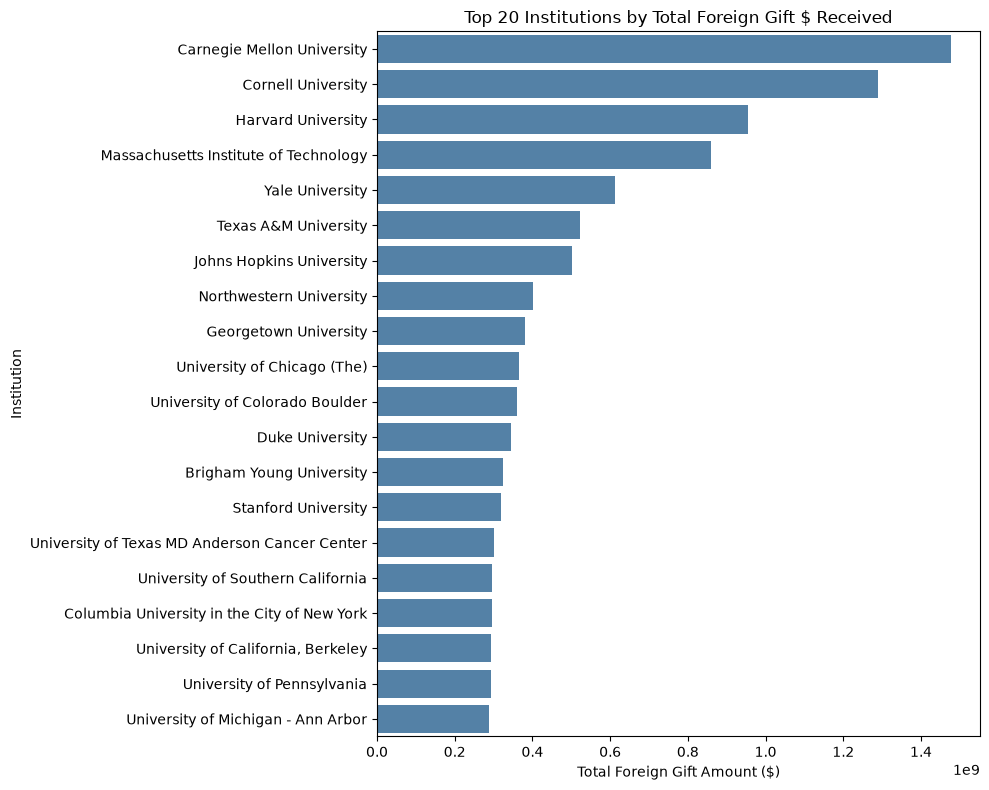

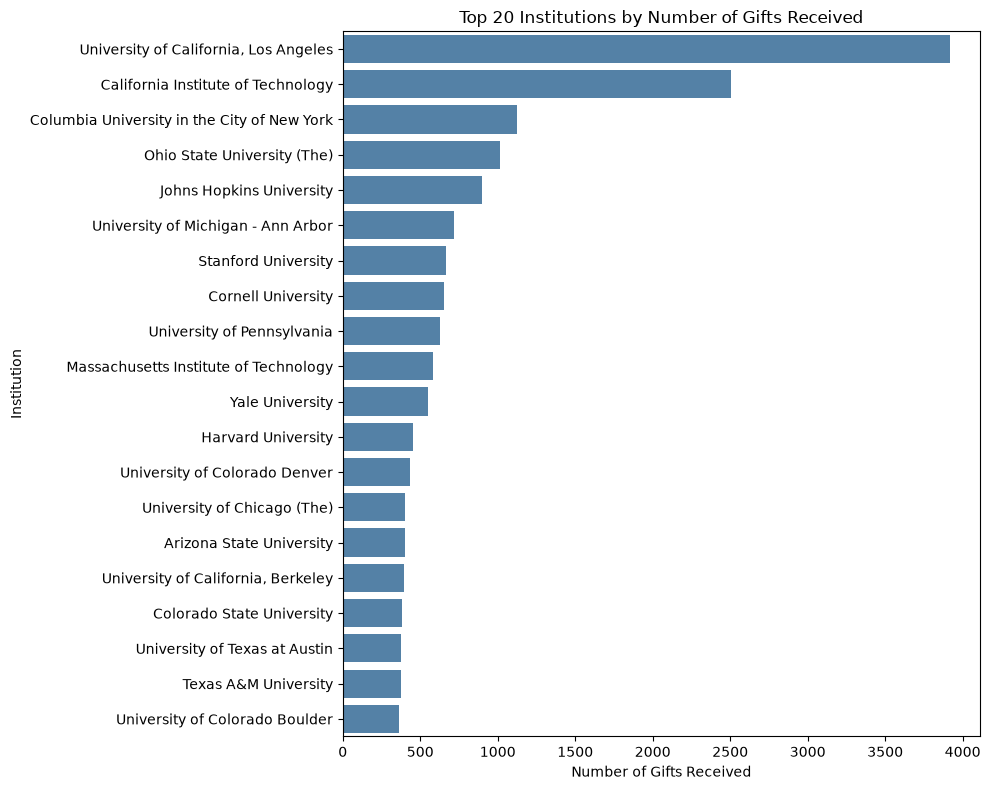

In [8]:
institution_col = "Institution Name"
amount_col = "Foreign Gift Amount"

df = pd.read_csv("ForeignGifts_edu.csv")
df[amount_col] = pd.to_numeric(df[amount_col], errors='coerce')
df = df.dropna(subset=[amount_col])

top20_amount = (
    df.groupby(institution_col)[amount_col]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 8))
sns.barplot(
    x=top20_amount.values,
    y=top20_amount.index,
    color="steelblue"  
)
plt.xlabel("Total Foreign Gift Amount ($)")
plt.ylabel("Institution")
plt.title("Top 20 Institutions by Total Foreign Gift $ Received")
plt.tight_layout()
plt.savefig("top20_by_amount.png")
plt.show()


top20_count = df[institution_col].value_counts().head(20)

plt.figure(figsize=(10, 8))
sns.barplot(
    x=top20_count.values,
    y=top20_count.index,
    color="steelblue"
)
plt.xlabel("Number of Gifts Received")
plt.ylabel("Institution")
plt.title("Top 20 Institutions by Number of Gifts Received")
plt.tight_layout()
plt.savefig("top20_by_count.png")
plt.show()

6 cont. - histogram of the amounts received by each university, and then label the median and the mean as vertical lines

mean amount: 588232.7172672832
median amount: 94615.0
dropped 24 rows that were <= 0 for the log plot


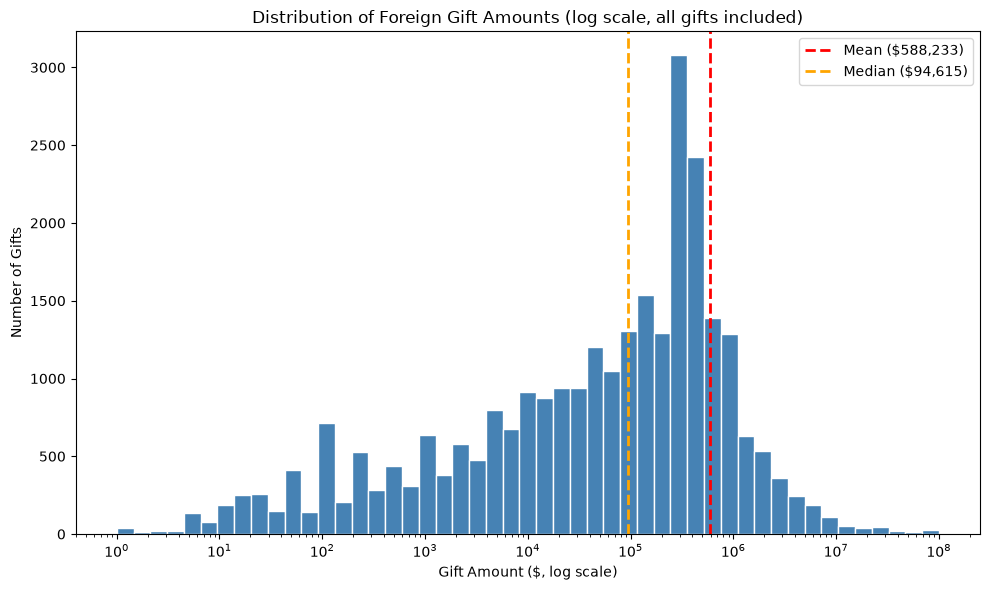

In [9]:
amount_col = "Foreign Gift Amount"

df = pd.read_csv("ForeignGifts_edu.csv")
df[amount_col] = pd.to_numeric(df[amount_col], errors='coerce')
df = df.dropna(subset=[amount_col])

mean_amount = df[amount_col].mean()
median_amount = df[amount_col].median()

print("mean amount:", mean_amount)
print("median amount:", median_amount)

positive_amounts = df[df[amount_col] > 0][amount_col]
print("dropped", len(df) - len(positive_amounts), "rows that were <= 0 for the log plot")

log_bins = np.geomspace(positive_amounts.min(), positive_amounts.max(), 50)

plt.figure(figsize=(10, 6))
plt.hist(positive_amounts, bins=log_bins, color="steelblue", edgecolor="white")
plt.axvline(mean_amount, color="red", linestyle="--", linewidth=2, label=f"Mean (${mean_amount:,.0f})")
plt.axvline(median_amount, color="orange", linestyle="--", linewidth=2, label=f"Median (${median_amount:,.0f})")
plt.xscale("log")
plt.xlabel("Gift Amount ($, log scale)")
plt.ylabel("Number of Gifts")
plt.title("Distribution of Foreign Gift Amounts (log scale, all gifts included)")
plt.legend()
plt.tight_layout()
plt.savefig("amount_histogram_log.png")
plt.show()

8 cont. - plot the flows from giftors to institutions (had to rendor in brower...extension was not loading correctly)

In [16]:
import plotly.graph_objects as go

country_col = "Country of Giftor"
institution_col = "Institution Name"
amount_col = "Foreign Gift Amount"

df = pd.read_csv("ForeignGifts_edu.csv")
df[amount_col] = pd.to_numeric(df[amount_col], errors='coerce')
df = df.dropna(subset=[amount_col])

TOP_N_COUNTRIES = 10
TOP_N_INSTITUTIONS = 10

top_countries = (
    df.groupby(country_col)[amount_col].sum()
    .sort_values(ascending=False)
    .head(TOP_N_COUNTRIES)
    .index
)
top_institutions = (
    df.groupby(institution_col)[amount_col].sum()
    .sort_values(ascending=False)
    .head(TOP_N_INSTITUTIONS)
    .index
)

sankey_df = df[df[country_col].isin(top_countries) & df[institution_col].isin(top_institutions)]

flows = sankey_df.groupby([country_col, institution_col])[amount_col].sum().reset_index()

print("number of country -> institution flows being plotted:", len(flows))

labels = list(top_countries) + list(top_institutions)

flows['source'] = flows[country_col].apply(lambda name: labels.index(name))
flows['target'] = flows[institution_col].apply(lambda name: labels.index(name))

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels
    ),
    link=dict(
        source=flows['source'],
        target=flows['target'],
        value=flows[amount_col]
    )
)])

fig.update_layout(
    title_text=f"Foreign Gift Flows: Top {TOP_N_COUNTRIES} Countries -> Top {TOP_N_INSTITUTIONS} Institutions",
    font_size=10
)

fig.write_html("country_institution_sankey.html")

fig.show(renderer="browser")

number of country -> institution flows being plotted: 89
